In [5]:
import os
import re
import glob
import sys
from concurrent.futures import ProcessPoolExecutor, as_completed

# ─── 0) Ensure we can import ODG and force CPU-only ──────────────────────────
parentdir = os.path.dirname(os.getcwd())
sys.path.insert(0, parentdir)

import OptimizedDataGenerator4 as ODG
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Input, Reshape, Conv3D, MaxPooling3D,
    Flatten, Dense, Dropout, Concatenate
)
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.models import Model

In [3]:
# ─── 1) Define the model builder ─────────────────────────────────────────────
def build_convolutional_model(input_shape=(13, 21, 20), num_classes=2):
    """
    Builds a 3D convolutional network that also consumes a scalar z_global input.
    - input_shape: tuple of (height, width, time_steps) as the generator returns it
    - num_classes: number of output classes (2 for binary)
    """
    # This matches the shape coming out of your TFRecord loader
    vol_input = tf.keras.Input(shape=input_shape, name='cluster')
    z_input   = tf.keras.Input(shape=(1,),        name='z_global')

    # swap (13,21,20) → (20,13,21)
    x = Permute((3, 1, 2), name='reorder')(vol_input)
    # now add channel axis for Conv3D: (20,13,21,1)
    x = Reshape(target_shape=(20, 13, 21, 1), name='add_channel')(x)

    # First 3D conv block
    x = tf.keras.layers.Conv3D(
        filters=32, kernel_size=(3, 3, 3), padding='same', activation='relu', name='conv3d_1'
    )(x)
    x = tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2), name='pool3d_1')(x)

    # Second 3D conv block
    x = tf.keras.layers.Conv3D(
        filters=64, kernel_size=(3, 3, 3), padding='same', activation='relu', name='conv3d_2'
    )(x)
    x = tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2), name='pool3d_2')(x)

    # Flatten and concatenate with z_global
    x = tf.keras.layers.Flatten(name='flatten')(x)
    x = tf.keras.layers.Concatenate(name='concat')([x, z_input])

    # Dense classification head
    x = tf.keras.layers.Dense(128, activation='relu', name='dense_1')(x)
    x = tf.keras.layers.Dropout(0.5, name='dropout')(x)

    if num_classes == 2:
        units, activation = 1, 'sigmoid'
    else:
        units, activation = num_classes, 'softmax'

    output = tf.keras.layers.Dense(units, activation=activation, name='output')(x)

    return tf.keras.Model(
        inputs=[vol_input, z_input],
        outputs=output,
        name='Conv3D_with_permute'
    )

Model: "Conv3D_with_permute"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cluster             │ (None, 13, 21,    │          0 │ -                 │
│ (InputLayer)        │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reorder (Permute)   │ (None, 20, 13,    │          0 │ cluster[0][0]     │
│                     │ 21)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_channel         │ (None, 20, 13,    │          0 │ reorder[0][0]     │
│ (Reshape)           │ 21, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_1 (Conv3D)   │ (None, 20, 13,    │        896 │ add_channel[0][0] │
│                     │ 21, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3d_1            │ (None, 10, 6, 10, │          0 │ conv3d_1[0][0]    │
│ (MaxPooling3D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_2 (Conv3D)   │ (None, 10, 6, 10, │     55,360 │ pool3d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3d_2            │ (None, 5, 3, 5,   │          0 │ conv3d_2[0][0]    │
│ (MaxPooling3D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4800)      │          0 │ pool3d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_global            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 4801)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ z_global[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    614,656 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 671,041 (2.56 MB)

 Trainable params: 671,041 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 337ms/step - accuracy: 0.3962 - loss: 2.0171 - val_accuracy: 0.5673 - val_loss: 0.6891
Epoch 2/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.4749 - loss: 0.6943 - val_accuracy: 0.6285 - val_loss: 0.6907
Epoch 3/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - accuracy: 0.5813 - loss: 0.6891 - val_accuracy: 0.5707 - val_loss: 0.6829
Epoch 4/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.4474 - loss: 0.6965 - val_accuracy: 0.6274 - val_loss: 0.6811
Epoch 5/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.5478 - loss: 0.6820 - val_accuracy: 0.6477 - val_loss: 0.6625
Epoch 6/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.5258 - loss: 0.6832 - val_accuracy: 0.6242 - val_loss: 0.6570
Epoch 7/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.5510 - loss: 0.6713 - val_accuracy: 0.6551 - val_loss: 0.6400
Epoch 8/120
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.5870 - loss: 0.6544 - val_acc

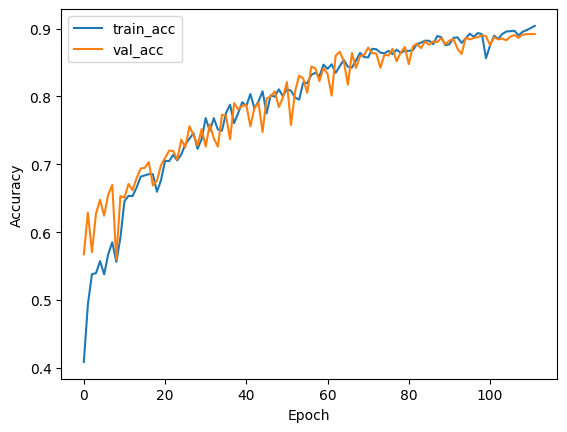

In [5]:
# ─── 2) Setup data generators ────────────────────────────────────────────────
BASE_DIR        = Path("/home/youeric/PixelML/smart_pixels_ml/filtering_models/filtering_records2048test")
TRAIN_DIR       = BASE_DIR / "tfrecords_train"
VALIDATION_DIR  = BASE_DIR / "tfrecords_validation"

train_gen = ODG.OptimizedDataGenerator(
    load_records           = True,
    tf_records_dir         = str(TRAIN_DIR),
    x_feature_description  = ['cluster', 'z_global']
)

val_gen = ODG.OptimizedDataGenerator(
    load_records           = True,
    tf_records_dir         = str(VALIDATION_DIR),
    x_feature_description  = ['cluster', 'z_global']
)

# ─── 3) Instantiate & compile ───────────────────────────────────────────────
input_shape = (13, 21, 20)    # matches generator output
num_classes = 2

model = build_convolutional_model(input_shape, num_classes)
loss = 'binary_crossentropy' if num_classes == 2 else 'categorical_crossentropy'

model.compile(
    optimizer='adam',
    loss=loss,
    metrics=['accuracy']
)

model.summary()

# ─── 4) Train ───────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=120,
    callbacks=callbacks
)

# ─── 5) Plot training & validation accuracy ────────────────────────────────
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [6]:
def build_convolutional_model2(input_shape=(13, 21, 20), num_classes=2):
    """
    - No Permute: assumes your loader emits (H, W, T)
    - Adds channel axis via Reshape
    - Applies a Dense(16) to z_global before concat
    - Inserts Dense(32) before the final output
    - Only one sigmoid/softmax activation at the end
    """
    vol_input = Input(shape=input_shape, name='cluster')
    z_input   = Input(shape=(1,), name='z_global')

    x = Reshape(target_shape=(*input_shape, 1), name='add_channel')(vol_input)
    x = Conv3D(32, (3,3,3), padding='same', activation='relu', name='conv3d_1')(x)
    x = MaxPooling3D((2,2,2), name='pool3d_1')(x)
    x = Conv3D(64, (3,3,3), padding='same', activation='relu', name='conv3d_2')(x)
    x = MaxPooling3D((2,2,2), name='pool3d_2')(x)
    x = Flatten(name='flatten')(x)

    z_dense = Dense(16, activation='relu', name='z_dense')(z_input)
    x = Concatenate(name='concat')([x, z_dense])

    x = Dense(64, activation='relu', name='dense_1')(x)
    x = Dropout(0.5, name='dropout')(x)
    x = Dense(32, activation='relu', name='dense_small')(x)

    if num_classes == 2:
        output = Dense(1, activation='sigmoid', name='output')(x)
        loss = 'binary_crossentropy'
    else:
        output = Dense(num_classes, activation='softmax', name='output')(x)
        loss = 'categorical_crossentropy'

    model = tf.keras.Model([vol_input, z_input], output, name='Conv3D_no_permute')
    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])
    return model

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 299ms/step - accuracy: 0.4033 - loss: 0.8265 - val_accuracy: 0.5557 - val_loss: 0.6899
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.5593 - loss: 0.6897 - val_accuracy: 0.5726 - val_loss: 0.6888
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.6521 - loss: 0.6854 - val_accuracy: 0.5815 - val_loss: 0.6793
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.5661 - loss: 0.6710 - val_accuracy: 0.6256 - val_loss: 0.6616
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.5219 - loss: 0.6766 - val_accuracy: 0.6063 - val_loss: 0.6518
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.6563 - loss: 0.6618 - val_accuracy: 0.6354 - val_loss: 0.6580
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.5221 - loss: 0.6707 - val_accuracy: 0.6527 - val_loss: 0.6326
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.7270 - loss: 0.6194 - val_acc

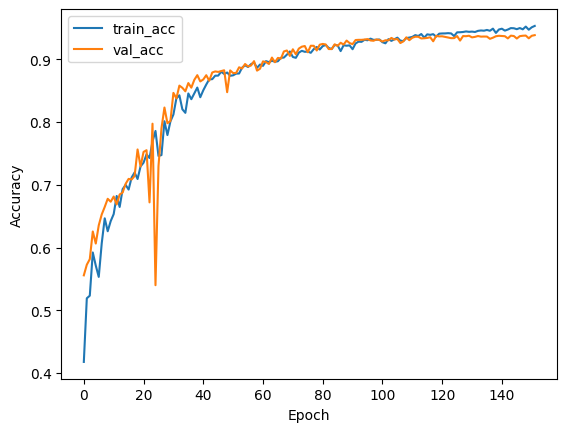

In [ ]:
# ─── 0) Define your hyper-params / config ──────────────────────────────────
config = {
    "kind": "polynomial_decay",
    "initial_lr": 1e-3,
    "end_lr":      1e-4,
    "power":       1.0,
}
epochs = 200

# ─── 1) Build your model (assumes build_convolutional_model2 is already in scope) ───
model = build_convolutional_model2(input_shape=(13,21,20), num_classes=2)

# ─── 2) Choose your optimizer (with polynomial decay) ────────────────────────
steps_per_epoch = len(train_gen)  # number of batches in an epoch

if config["kind"] == "polynomial_decay":
    lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
        initial_learning_rate = config["initial_lr"],
        decay_steps           = steps_per_epoch * epochs,
        end_learning_rate     = config.get("end_lr", 1e-5),
        power                 = config.get("power", 1.0)
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
else:
    # fallback to a plain Adam
    optimizer = tf.keras.optimizers.Adam(learning_rate=config["initial_lr"])

# ─── 3) Compile ─────────────────────────────────────────────────────────────
model.compile(
    optimizer = optimizer,
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

model.summary()

# ─── 4) Callbacks (early stopping with patience=40) ─────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor               = 'val_loss',
        patience              = 40,
        restore_best_weights  = True
    )
]

# ─── 5) Train for 200 epochs ────────────────────────────────────────────────
history = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = epochs,
    callbacks       = callbacks
)

# ─── 6) Plot ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],    label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

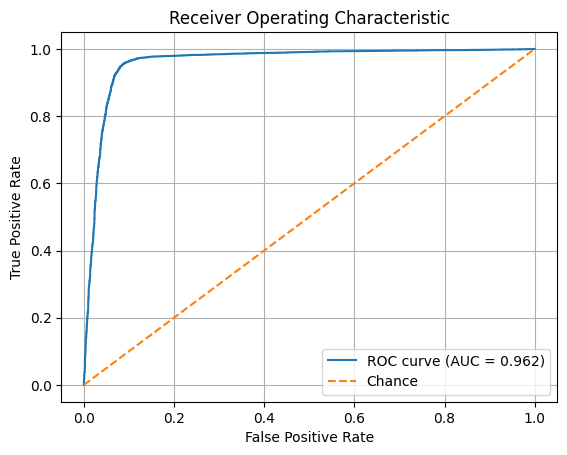

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1) Get predicted probabilities for the positive class on the val set
#    model.predict(val_gen) will return an array of shape (N,1)
y_score = model.predict(val_gen, verbose=0).ravel()

# 2) Gather the true labels by iterating over the Sequence
y_true = np.concatenate([y for _, y in (val_gen[i] for i in range(len(val_gen)))])

# 3) Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# 4) Plot
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], '--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

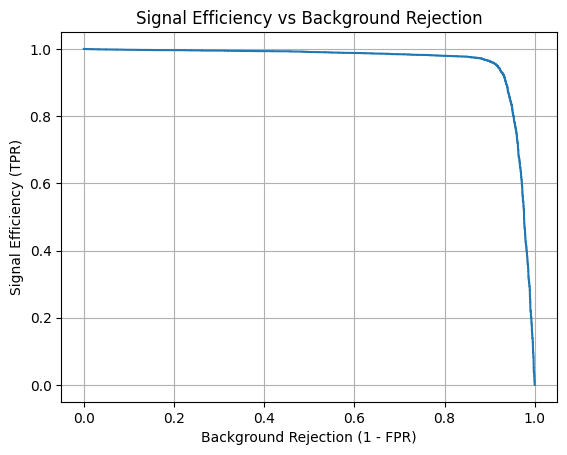

In [10]:
import numpy as np
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# 1) Get model scores and true labels
y_score = model.predict(val_gen, verbose=0).ravel()
y_true  = np.concatenate([y for _, y in (val_gen[i] for i in range(len(val_gen)))])

# 2) Compute ROC points
fpr, tpr, _ = roc_curve(y_true, y_score)

# 3) Compute background rejection
background_rejection = 1.0 - fpr

# 4) Plot
plt.figure()
plt.plot(background_rejection, tpr)
plt.xlabel('Background Rejection (1 - FPR)')
plt.ylabel('Signal Efficiency (TPR)')
plt.title('Signal Efficiency vs Background Rejection')
plt.grid(True)
plt.show()
